# 01 — Your First Diffraction Pattern

**Time: ~15 minutes.**  No prior MIDAS knowledge assumed; some Python
familiarity helps.

## What you'll learn

By the end of this notebook you will have:

1. Loaded a real diffraction image from a CeO₂ calibrant on a Pilatus
   detector.
2. Visualised the raw 2-D image and spotted the Debye-Scherrer rings
   by eye.
3. Built a `midas-integrate-v2` `IntegrationSpec` from the calibration
   parameter file shipped with MIDAS.
4. Performed your first **radial integration** to collapse the 2-D
   image into a 1-D profile.
5. Used Bragg's law to predict where the CeO₂ rings should appear and
   confirmed your peaks land at the right radii.

## Background — what's actually happening

A high-energy X-ray beam hits a polycrystalline calibrant (here cerium
dioxide, CeO₂). Each crystallographic plane in the powder diffracts
X-rays out at a fixed angle 2θ given by **Bragg's law**:

$$ \lambda = 2 d_{hkl} \sin(\theta) $$

where λ is the X-ray wavelength and $d_{hkl}$ is the spacing of the
lattice plane (hkl). Because the powder is randomly oriented, the
diffracted X-rays form **cones** of half-angle 2θ around the beam axis.

When those cones hit a flat 2-D detector downstream of the sample they
intersect it as **rings** — the Debye-Scherrer pattern. Each ring's
radius (in pixels) tells you the angle 2θ, which tells you d, which
tells you the lattice.

**Radial integration** is the operation that converts the 2-D image
(with all its rings) into a 1-D plot of intensity vs. radius. You can
then read off peak positions, widths, and intensities to do quantitative
analysis (Rietveld refinement, peak fitting, strain analysis, …).


## Setup

We use the example dataset shipped at
`FF_HEDM/Example/Calibration/CeO2_Pil_100x100_..._001956.tif`. The
calibration parameters (sample-to-detector distance, beam centre,
distortion, wavelength) are in `parameters.txt` next to it.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

# Locate the dataset relative to this notebook.
HERE = Path.cwd() if Path.cwd().name == "notebooks" else Path("notebooks")
REPO = HERE.resolve().parents[2]
DATA = REPO / "FF_HEDM" / "Example" / "Calibration"
PARAMS = DATA / "parameters.txt"
IMAGE  = DATA / "CeO2_Pil_100x100_att000_650mm_71p676keV_001956.tif"
DARK   = DATA / "dark_CeO2_Pil_100x100_att000_650mm_71p676keV_001975.tif"

assert PARAMS.exists() and IMAGE.exists() and DARK.exists(), (
    f"Example dataset not found under {DATA}. "
    "This notebook is meant to be run from inside the MIDAS repo."
)
print("OK: dataset found")


OK: dataset found


## Step 1 — Load and look at the raw image

The calibrant frame is a single TIFF. We also have a dark-current
frame which we subtract to remove the detector pedestal.


In [2]:
import tifffile

img_raw = tifffile.imread(IMAGE).astype(np.float64)
dark    = tifffile.imread(DARK).astype(np.float64)
if dark.ndim == 3:                # some MIDAS examples ship a 3-D dark
    dark = dark.mean(axis=0)

# Subtract dark, clip negatives (electronics noise can take a few px <0).
img = np.clip(img_raw - dark, 0.0, None)
print(f"image shape: {img.shape}, dtype: {img.dtype}")
print(f"intensity range: [{img.min():.1f}, {img.max():.1f}], "
      f"mean: {img.mean():.1f}")


image shape: (1679, 1475), dtype: float64
intensity range: [0.0, 2340557.0], mean: 994.3


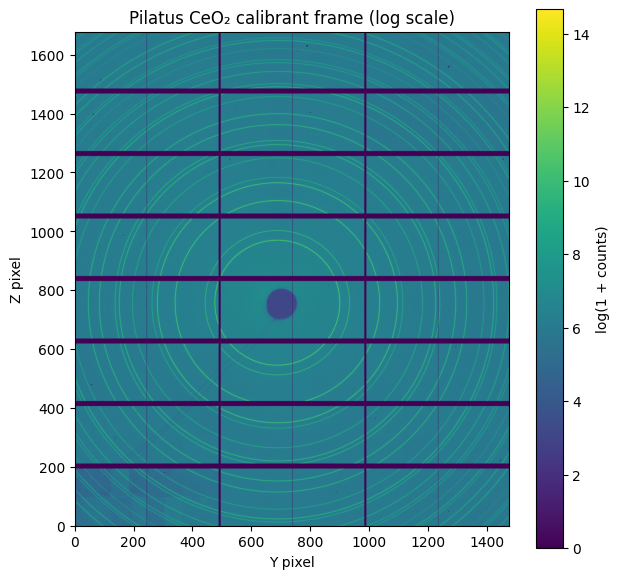

In [3]:
# Visualise on a log scale — diffraction images have huge dynamic range.
fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(np.log1p(img), cmap="viridis", origin="lower")
ax.set_title("Pilatus CeO₂ calibrant frame (log scale)")
ax.set_xlabel("Y pixel")
ax.set_ylabel("Z pixel")
fig.colorbar(im, ax=ax, label="log(1 + counts)")
plt.show()


**What you should see:** concentric rings, brighter near the centre and
fading outward. The brightest ring (closest to centre) is CeO₂'s (111)
reflection. There are also rectangular dark stripes — those are
**module gaps** in the Pilatus detector; we'll mask those later.

**Try it:** zoom into the central region by setting `ax.set_xlim` /
`set_ylim`. Notice that the rings are **slightly elliptical**, not
perfectly circular — that's because the detector is mildly tilted
relative to the beam. Calibration measures and corrects this.


## Step 2 — Load the calibration parameters

`parameters.txt` is a v1-style key-value file. `midas-integrate-v2`
reads it into an `IntegrationSpec` — a dataclass holding torch tensors
for everything that's refinable (Lsd, beam centre, tilts, distortion,
parallax, wavelength).


In [4]:
from midas_integrate_v2 import spec_from_v1_paramstest

spec = spec_from_v1_paramstest(PARAMS, requires_grad=False)

# Coarsen the binning a bit so this notebook runs in seconds.
# (paramters.txt sets RBinSize=0.25 which builds a 4760-bin profile;
#  we'll use 2-px bins for visualisation.)
spec.RBinSize = 2.0
spec.EtaBinSize = 5.0

print(f"Detector:    {spec.NrPixelsY} × {spec.NrPixelsZ} px @ {spec.pxY} µm")
print(f"Lsd:         {float(spec.Lsd) / 1000:.1f} mm")
print(f"Beam centre: ({float(spec.BC_y):.2f}, {float(spec.BC_z):.2f}) px")
print(f"Tilts:       tx={float(spec.tx):.3f}°, "
      f"ty={float(spec.ty):.3f}°, tz={float(spec.tz):.3f}°")
print(f"Wavelength:  {float(spec.Wavelength):.6f} Å  "
      f"(energy ≈ {12.398 / float(spec.Wavelength):.2f} keV)")
print(f"R bins:      RMin={spec.RMin}, RMax={spec.RMax}, "
      f"RBinSize={spec.RBinSize} → {spec.n_r_bins} bins")
print(f"η bins:      EtaMin={spec.EtaMin}, EtaMax={spec.EtaMax}, "
      f"EtaBinSize={spec.EtaBinSize} → {spec.n_eta_bins} bins")


Detector:    1475 × 1679 px @ 172.0 µm
Lsd:         657.4 mm
Beam centre: (685.49, 921.03) px
Tilts:       tx=0.000°, ty=0.201°, tz=0.447°
Wavelength:  0.172973 Å  (energy ≈ 71.68 keV)
R bins:      RMin=10.0, RMax=1200.0, RBinSize=2.0 → 595 bins
η bins:      EtaMin=-180.0, EtaMax=180.0, EtaBinSize=5.0 → 72 bins


**What each parameter means** (first physics here):

- **Lsd**: distance from sample to detector along the beam, in µm.
  Larger Lsd ⇒ smaller 2θ for the same R.
- **BC_y, BC_z**: pixel coordinates where the un-deflected beam would
  hit the detector. The centre of the diffraction rings.
- **tx, ty, tz**: tilt angles of the detector relative to perpendicular
  to the beam, in degrees. Small but matter for accurate calibration.
- **Wavelength**: λ in Ångströms. Set by the beamline monochromator.
- **R bins / η bins**: the polar grid we'll bin the detector into.
  R is radial pixel distance from the beam centre; η is the azimuthal
  angle around the beam axis (η = 0 conventionally points "up" along
  +Z).


## Step 3 — Your first integration

We'll use the **subpixel-oversampled hard-binning** path
(`SubpixelBinGeometry` with K=2). It splits each pixel into 2×2
subpixels, hard-bins each, and is a good compromise between speed and
edge accuracy.


In [5]:
from midas_integrate_v2 import SubpixelBinGeometry, integrate_subpixel

# Build the binning geometry once for this spec. Internally:
#   - evaluates (R, η) at every pixel using the spec's geometry,
#   - assigns each pixel (or subpixel) to its (R bin, η bin),
#   - applies ImTransOpt automatically (the parameter file says
#     ImTransOpt 2 = flip Z, and v2 handles this for us).
geom = SubpixelBinGeometry.from_spec(spec, K=2)
print(f"Geometry built: {geom.n_subpixels} subpixels × "
      f"{spec.NrPixelsY * spec.NrPixelsZ} pixels = "
      f"{geom.n_subpixels * spec.NrPixelsY * spec.NrPixelsZ:,} contributions")
print(f"Output shape: ({spec.n_eta_bins}, {spec.n_r_bins})")


Geometry built: 4 subpixels × 2476525 pixels = 9,906,100 contributions
Output shape: (72, 595)


In [6]:
# Now integrate the image. The output is 2-D: (η bins) × (R bins).
img_t = torch.from_numpy(img)
int2d = integrate_subpixel(img_t, geom, normalize=True)
print(f"int2d: shape={tuple(int2d.shape)}, dtype={int2d.dtype}")


int2d: shape=(72, 595), dtype=torch.float64


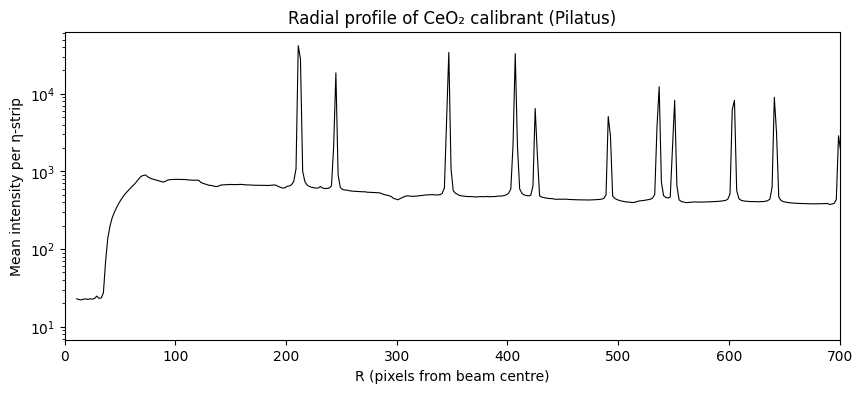

In [7]:
# Collapse over η to get the 1-D profile.
prof = int2d.mean(dim=0).numpy()
n_r = spec.n_r_bins
r_axis_px = spec.RMin + spec.RBinSize * (np.arange(n_r) + 0.5)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(r_axis_px, prof, "k-", lw=0.8)
ax.set_xlabel("R (pixels from beam centre)")
ax.set_ylabel("Mean intensity per η-strip")
ax.set_title("Radial profile of CeO₂ calibrant (Pilatus)")
ax.set_xlim(0, 700)
ax.set_yscale("log")
plt.show()


**You should see** several sharp peaks rising above the background.
Each peak is one Debye-Scherrer ring. The strongest one near
R ≈ 211 px is CeO₂'s (111) reflection.

The wide rise on the very-left (R < 100 px) is mostly beam-stop /
detector-edge artefact, not real diffraction.


## Step 4 — Confirm peaks with Bragg's law

CeO₂ (cubic, $a$ = 5.411 Å) has these low-order reflections:

| (hkl) | d (Å)  |
|-------|--------|
| (111) | 3.124  |
| (200) | 2.706  |
| (220) | 1.913  |
| (311) | 1.633  |
| (222) | 1.562  |
| (400) | 1.353  |

Bragg's law gives 2θ = 2 arcsin(λ / 2d), and the radius on the
detector is then R = (Lsd / px) · tan(2θ).


In [8]:
def predict_R_px(d_A, *, Lsd_um, px_um, lam_A):
    """Predicted ring radius in pixels for a given d-spacing."""
    two_theta = 2.0 * np.arcsin(lam_A / (2.0 * d_A))
    return (Lsd_um / px_um) * np.tan(two_theta)


CEO2_RINGS = [
    ((1, 1, 1), 3.124),
    ((2, 0, 0), 2.706),
    ((2, 2, 0), 1.913),
    ((3, 1, 1), 1.633),
    ((2, 2, 2), 1.562),
    ((4, 0, 0), 1.353),
]
Lsd_um = float(spec.Lsd)
px_um  = spec.pxY
lam_A  = float(spec.Wavelength)

predictions = []
for hkl, d in CEO2_RINGS:
    R_pred = predict_R_px(d, Lsd_um=Lsd_um, px_um=px_um, lam_A=lam_A)
    predictions.append((hkl, d, R_pred))
    print(f"({hkl[0]}{hkl[1]}{hkl[2]})  d={d:.3f} Å  →  "
          f"2θ={np.degrees(2 * np.arcsin(lam_A / (2 * d))):.3f}°  "
          f"→  R={R_pred:6.1f} px")


(111)  d=3.124 Å  →  2θ=3.173°  →  R= 211.9 px
(200)  d=2.706 Å  →  2θ=3.663°  →  R= 244.7 px
(220)  d=1.913 Å  →  2θ=5.182°  →  R= 346.7 px
(311)  d=1.633 Å  →  2θ=6.072°  →  R= 406.6 px
(222)  d=1.562 Å  →  2θ=6.348°  →  R= 425.2 px
(400)  d=1.353 Å  →  2θ=7.330°  →  R= 491.7 px


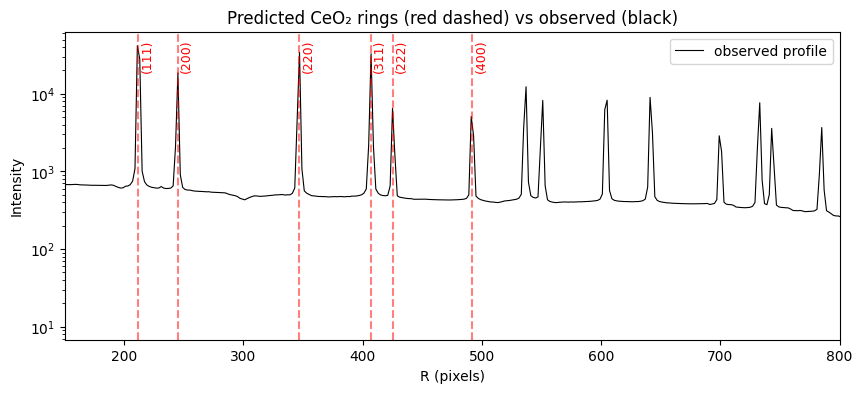

In [9]:
# Overlay the predictions on the radial profile.
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(r_axis_px, prof, "k-", lw=0.8, label="observed profile")
ax.set_yscale("log")
ax.set_xlim(150, 800)

for hkl, d, R_pred in predictions:
    if R_pred > 800:
        continue
    ax.axvline(R_pred, color="red", ls="--", alpha=0.5)
    ax.text(R_pred + 2, prof.max() * 0.5,
            f"({hkl[0]}{hkl[1]}{hkl[2]})", color="red",
            rotation=90, fontsize=9)

ax.set_xlabel("R (pixels)")
ax.set_ylabel("Intensity")
ax.set_title("Predicted CeO₂ rings (red dashed) vs observed (black)")
ax.legend()
plt.show()


**Every red dashed line should land on top of (or very close to) an
observed peak.** That's the calibration working — the geometry in
`parameters.txt` was refined to put the predicted rings on the
observed peaks.

If the lines were systematically *off* (all shifted left or right,
say), that would mean Lsd is wrong. If they were off by different
amounts at different radii, that would point to wavelength or
distortion. Notebook **03 — Refining Calibration** is all about how
v2 refines geometry to get this alignment.


## Recap — what just happened

```
parameters.txt        ─→  spec_from_v1_paramstest()    ─→  IntegrationSpec
calibrant TIFF + dark ─→  load + subtract              ─→  raw image (numpy)
IntegrationSpec       ─→  SubpixelBinGeometry.from_spec(K=2)
SubpixelBinGeometry   ─→  integrate_subpixel(image)    ─→  (n_eta, n_r) array
(n_eta, n_r)          ─→  mean over η                  ─→  1-D profile
```

You did this with **three lines of v2 code** (not counting plotting):

```python
spec  = spec_from_v1_paramstest(PARAMS)
geom  = SubpixelBinGeometry.from_spec(spec, K=2)
prof  = integrate_subpixel(img, geom).mean(dim=0)
```

## Try it yourself

1. Change `K=2` to `K=4`. How does the profile change? (Hint: peaks
   should narrow slightly at the cost of integration time.)
2. Change `K=2` to `K=1` (one sample per pixel). Compare; the
   bin-edge quantisation should be more visible at high R.
3. Set `spec.RBinSize = 0.5`. The profile gets longer (more bins) and
   the peaks get sharper. What happens to the noise floor?
4. Use `np.argmax` to find the index of the brightest peak in the
   first-ring band (R between 200 and 230 px). What's the centroid R?

## Next: 02 — Geometry: How Each Parameter Shapes the Pattern

You'll see what BC, Lsd, tilts, and distortion each do *visually* on
the integrated image. That intuition is what makes calibration
refinement (notebook 03) make sense.
